In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/archive (2).zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# List files in the extracted directory (optional, for verification)
print(f"Files extracted to {extract_dir}: {os.listdir(extract_dir)}")

# Now, read the CSV files from the extracted directory
matches = pd.read_csv(os.path.join(extract_dir, 'matches.csv'))
deliveries = pd.read_csv(os.path.join(extract_dir, 'deliveries.csv'))

Files extracted to /content/extracted_data: ['matches.csv', 'deliveries.csv']


In [13]:
# merge match info into deliveries
df = deliveries.merge(matches, left_on='match_id', right_on='id', how='left')


# only look at run-chases (2nd innings)
chase = df[df['inning'] == 2].copy()

# calculate balls remaining and runs remaining per match
chase['total_balls'] = chase.groupby('match_id')['ball'].transform('count')
chase['cumulative_runs'] = chase.groupby('match_id')['total_runs'].cumsum()
chase['target'] = chase.groupby('match_id')['total_runs'].transform('sum') + 1

chase['runs_remaining'] = chase['target'] - chase['cumulative_runs']
chase['balls_bowled'] = chase.groupby('match_id').cumcount() + 1
chase['balls_remaining'] = chase['total_balls'] - chase['balls_bowled']

# required run rate at that point
chase['required_rr'] = (chase['runs_remaining'] * 6) / chase['balls_remaining'].replace(0, np.nan)

# pressure = required run rate > 10
pressure_balls = chase[chase['required_rr'] > 10]

In [14]:
def strike_rate(data, group_col='batter'): # Changed 'batsman' to 'batter'
    grouped = data.groupby(group_col).agg(
        runs=('batsman_runs', 'sum'),
        balls=('batsman_runs', 'count')
    )
    grouped['strike_rate'] = (grouped['runs'] / grouped['balls']) * 100
    return grouped

overall_sr = strike_rate(chase)
pressure_sr = strike_rate(pressure_balls)

clutch = overall_sr.join(pressure_sr, lsuffix='_overall', rsuffix='_pressure')
clutch = clutch[clutch['balls_overall'] >= 100] # min balls filter, avoid noise
clutch['clutch_factor'] = clutch['strike_rate_pressure'] - clutch['strike_rate_overall']
clutch_sorted = clutch.sort_values('clutch_factor', ascending=False)

print(clutch_sorted.head(15))

                   runs_overall  balls_overall  strike_rate_overall  \
batter                                                                
AP Tare                     142            110           129.090909   
HV Patel                    123            107           114.953271   
JEC Franklin                209            221            94.570136   
TM Head                     172            101           170.297030   
SC Ganguly                  628            612           102.614379   
HH Gibbs                    414            416            99.519231   
MD Mishra                   149            128           116.406250   
ST Jayasuriya               319            225           141.777778   
CL White                    288            288           100.000000   
DP Conway                   282            224           125.892857   
IK Pathan                   577            479           120.459290   
Washington Sundar           221            179           123.463687   
DJ Mit

In [15]:
def economy_rate(data, group_col='bowler'):
    grouped = data.groupby(group_col).agg(
        runs_conceded=('total_runs', 'sum'),
        balls=('total_runs', 'count')
    )
    grouped['economy'] = (grouped['runs_conceded'] / grouped['balls']) * 6
    return grouped

overall_econ = economy_rate(chase)
pressure_econ = economy_rate(pressure_balls)

bowl_clutch = overall_econ.join(pressure_econ, lsuffix='_overall', rsuffix='_pressure')
bowl_clutch = bowl_clutch[bowl_clutch['balls_overall'] >= 100]  # min balls filter

# lower pressure economy vs overall = better under pressure
bowl_clutch['clutch_factor'] = bowl_clutch['economy_overall'] - bowl_clutch['economy_pressure']
bowl_clutch_sorted = bowl_clutch.sort_values('clutch_factor', ascending=False)

print(bowl_clutch_sorted.head(15))


                  runs_conceded_overall  balls_overall  economy_overall  \
bowler                                                                    
AA Chavan                           200            151         7.947020   
RE van der Merwe                    230            211         6.540284   
MJ Santner                          200            163         7.361963   
Sohail Tanvir                       105            116         5.431034   
S Lamichhane                        154            115         8.034783   
BCJ Cutting                         223            158         8.468354   
Joginder Sharma                     256            159         9.660377   
VY Mahesh                           193            123         9.414634   
M Theekshana                        401            315         7.638095   
J Yadav                             163            157         6.229299   
J Suchith                           287            180         9.566667   
Rasikh Salam             

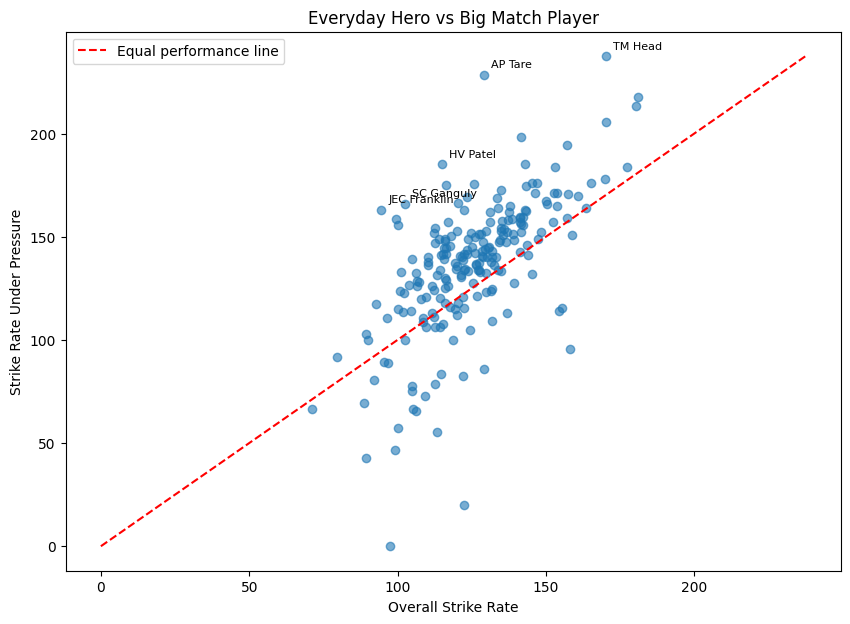

In [16]:
plt.figure(figsize=(10,7))
plt.scatter(clutch['strike_rate_overall'], clutch['strike_rate_pressure'], alpha=0.6)

# diagonal reference line (y = x)
max_val = max(clutch['strike_rate_overall'].max(), clutch['strike_rate_pressure'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Equal performance line')

# label top 5 clutch players
top5 = clutch_sorted.head(5)
for name, row in top5.iterrows():
    plt.annotate(name, (row['strike_rate_overall'], row['strike_rate_pressure']),
                 fontsize=8, xytext=(5,5), textcoords='offset points')

plt.xlabel('Overall Strike Rate')
plt.ylabel('Strike Rate Under Pressure')
plt.title('Everyday Hero vs Big Match Player')
plt.legend()
plt.show()

In [17]:
# did the toss winner also win the match?
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']

# overall toss impact
overall_toss_win_pct = matches['toss_win_match_win'].mean() * 100
print(f"Overall: Toss winner also wins match {overall_toss_win_pct:.1f}% of the time")

# by venue (min 5 matches to avoid noise)
venue_toss = matches.groupby('venue').agg(
    matches_played=('id', 'count'),
    toss_win_match_win_pct=('toss_win_match_win', 'mean')
)
venue_toss['toss_win_match_win_pct'] *= 100
venue_toss = venue_toss[venue_toss['matches_played'] >= 5].sort_values(
    'toss_win_match_win_pct', ascending=False
)

print(venue_toss)

Overall: Toss winner also wins match 50.6% of the time
                                                    matches_played  \
venue                                                                
Holkar Cricket Stadium                                           9   
Barabati Stadium                                                 7   
Punjab Cricket Association IS Bindra Stadium                    10   
SuperSport Park                                                 12   
Maharashtra Cricket Association Stadium                         22   
Kingsmead                                                       15   
Brabourne Stadium                                               10   
Newlands                                                         7   
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cr...              14   
JSCA International Stadium Complex                               7   
Sharjah Cricket Stadium                                         28   
Subrata Roy Sahara Stadium         

In [18]:
decision_impact = matches.groupby('toss_decision').agg(
    matches=('id', 'count'),
    win_rate=('toss_win_match_win', 'mean')
)
decision_impact['win_rate'] *= 100
print(decision_impact)


               matches   win_rate
toss_decision                    
bat                391  45.268542
field              704  53.551136


/tmp/ipykernel_2221/1083281272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='toss_win_match_win_pct', y=top_venues.index, data=top_venues, palette='coolwarm')


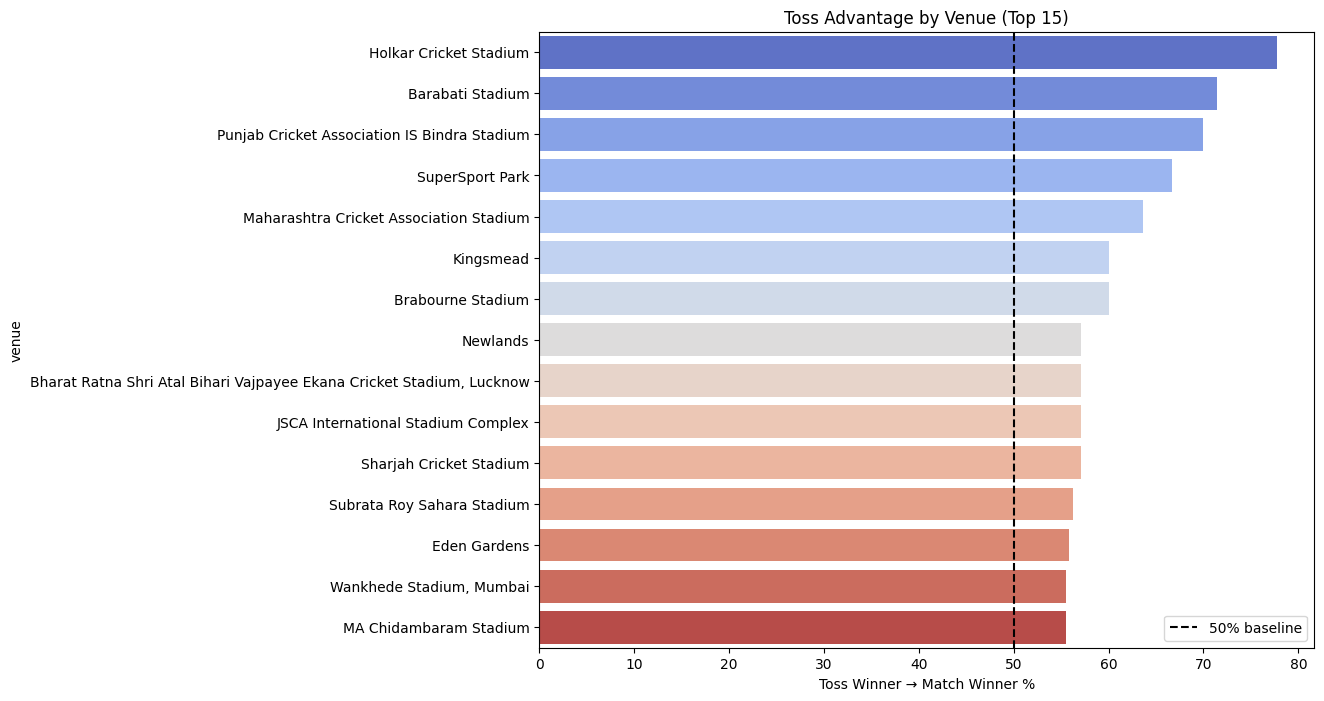

In [19]:
plt.figure(figsize=(10,8))
top_venues = venue_toss.head(15)
sns.barplot(x='toss_win_match_win_pct', y=top_venues.index, data=top_venues, palette='coolwarm')
plt.xlabel('Toss Winner → Match Winner %')
plt.title('Toss Advantage by Venue (Top 15)')
plt.axvline(50, color='black', linestyle='--', label='50% baseline')
plt.legend()
plt.show()